Características del dataset

✅ 42.681 eventos de velocidad

✅ 5 dispositivos en 5 calles distintas

| Dispositivo | Calle | Límite |
| ----------- | ----- | -------|
|speed-01 |	Zona Escolar |	30 km/h |
|speed-02 |	Zona Residencial |	40 km/h |
|speed-03 |	Avenida Principal |	50 km/h |
|speed-04 |	Corredor Comercial | 60 km/h |
|speed-05 |	Periférica Urbana |	70 km/h |

✅ Horas pico simuladas

Mañana: 07:00–09:00
Tarde: 17:00–20:00

✅ Variación mensual

El volumen de tráfico aumenta progresivamente durante el año.

✅ Tendencia histórica

Datos distribuidos durante todo 2025.
Permite gráficos por mes, trimestre y evolución temporal.

✅ Velocidades coherentes por zona

Zona Escolar → velocidades bajas.

Avenida Principal → velocidades medias-altas.

Periférica Urbana → velocidades más elevadas.


✅ Eventos de exceso de velocidad

Incluye activación de alarmas asociadas.
Gráficas que podrás construir


In [12]:
#Importar librerías
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
from datetime import datetime

# Configuración visual
pd.set_option('display.max_columns', None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


# Carga y Preparaciond de datos

In [13]:
# Cargar datasets

events_df = pd.read_csv("speed_events_dashboard.csv")

devices_df = pd.read_csv("user_devices_dashboard.csv")

print("Eventos:", events_df.shape)
print("Dispositivos:", devices_df.shape)

Eventos: (42681, 8)
Dispositivos: (5, 3)


In [14]:
events_df.head()

,device_id,timestamp,speed,speedLimit,exceeded,alarmActivated,day,hour
0,speed-01,1735719502,39.05,30,True,True,Wednesday,8
1,speed-01,1735767809,33.37,30,True,True,Wednesday,21
2,speed-01,1735719632,29.69,30,False,False,Wednesday,8
3,speed-01,1735742906,14.61,30,False,False,Wednesday,14
4,speed-01,1735753287,29.55,30,False,False,Wednesday,17


In [15]:
# Unir eventos con nombres de calles
df = events_df.merge(
    devices_df,
    on="device_id",
    how="left"
)

df.head()

,device_id,timestamp,speed,speedLimit,exceeded,alarmActivated,day,hour,user_id,device_name
0,speed-01,1735719502,39.05,30,True,True,Wednesday,8,admin,Zona Escolar
1,speed-01,1735767809,33.37,30,True,True,Wednesday,21,admin,Zona Escolar
2,speed-01,1735719632,29.69,30,False,False,Wednesday,8,admin,Zona Escolar
3,speed-01,1735742906,14.61,30,False,False,Wednesday,14,admin,Zona Escolar
4,speed-01,1735753287,29.55,30,False,False,Wednesday,17,admin,Zona Escolar


In [16]:
# Convertir timestamp a fecha
df["datetime"] = pd.to_datetime(
    df["timestamp"],
    unit="s"
)

df["date"] = df["datetime"].dt.date

df["month"] = df["datetime"].dt.strftime("%Y-%m")

df["year"] = df["datetime"].dt.year

df["month_name"] = df["datetime"].dt.strftime("%B")

df.head()

,device_id,timestamp,speed,speedLimit,exceeded,alarmActivated,day,hour,user_id,device_name,datetime,date,month,year,month_name
0,speed-01,1735719502,39.05,30,True,True,Wednesday,8,admin,Zona Escolar,2025-01-01 08:18:22,2025-01-01,2025-01,2025,January
1,speed-01,1735767809,33.37,30,True,True,Wednesday,21,admin,Zona Escolar,2025-01-01 21:43:29,2025-01-01,2025-01,2025,January
2,speed-01,1735719632,29.69,30,False,False,Wednesday,8,admin,Zona Escolar,2025-01-01 08:20:32,2025-01-01,2025-01,2025,January
3,speed-01,1735742906,14.61,30,False,False,Wednesday,14,admin,Zona Escolar,2025-01-01 14:48:26,2025-01-01,2025-01,2025,January
4,speed-01,1735753287,29.55,30,False,False,Wednesday,17,admin,Zona Escolar,2025-01-01 17:41:27,2025-01-01,2025-01,2025,January


In [17]:
# Validación general
print("Total registros:", len(df))

print("\nCalles:")
print(df["device_name"].unique())

print("\nPeriodo:")
print(df["datetime"].min())
print(df["datetime"].max())

Total registros: 42681

Calles:
<StringArray>
[      'Zona Escolar',   'Zona Residencial',  'Avenida Principal',
 'Corredor Comercial',  'Periférica Urbana']
Length: 5, dtype: str

Periodo:
2025-01-01 02:08:23
2025-12-31 23:31:22


# Cálculo de KPIs

In [18]:
# Total de vehículos detectados
total_vehiculos = len(df)

# Vehículos infractores
total_infractores = df["exceeded"].sum()

# Alarmas activadas
total_alarmas = df["alarmActivated"].sum()

# Porcentaje de infractores
porcentaje_infractores = (
    total_infractores / total_vehiculos
) * 100

print(f"Vehículos detectados: {total_vehiculos:,}")
print(f"Infractores: {total_infractores:,}")
print(f"Alarmas: {total_alarmas:,}")
print(f"Porcentaje infractores: {porcentaje_infractores:.2f}%")

Vehículos detectados: 42,681
Infractores: 18,469
Alarmas: 16,610
Porcentaje infractores: 43.27%


Un KPI (Key Performance Indicator o Indicador Clave de Desempeño) es una métrica cuantificable que evalúa el éxito y el progreso de una organización, campaña o proceso hacia sus objetivos estratégicos.

In [19]:
#  Dashboard de KPIs

# Crear subplots 2x2 tipo indicadores
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}]
    ]
)

# KPI 1
fig.add_trace(go.Indicator(
    mode="number",
    value=total_vehiculos,
    title={"text": "Vehículos Detectados"}
), row=1, col=1)

# KPI 2
fig.add_trace(go.Indicator(
    mode="number",
    value=total_infractores,
    title={"text": "Vehículos Infractores"}
), row=1, col=2)

# KPI 3
fig.add_trace(go.Indicator(
    mode="number",
    value=total_alarmas,
    title={"text": "Alarmas Activadas"}
), row=2, col=1)

# KPI 4
fig.add_trace(go.Indicator(
    mode="number",
    value=porcentaje_infractores,
    number={"suffix": "%"},
    title={"text": "% Infractores"}
), row=2, col=2)

# Layout final
fig.update_layout(
    height=450,
    title="Resumen General del Sistema",
    margin=dict(t=60, b=20, l=20, r=20)
)

fig.show()

# Graficas

## Nivel 1:

Estas responden preguntas de negocio o seguridad vial.

## 1. Excesos de velocidad por hora

In [20]:
excesos_hora = (
    df[df["exceeded"] == True]
    .groupby("hour")
    .size()
    .reset_index(name="cantidad")
)

fig = px.bar(
    excesos_hora,
    x="hour",
    y="cantidad",
    title="Excesos de Velocidad por Hora",
    labels={
        "hour": "Hora",
        "cantidad": "Cantidad de Excesos"
    }
)

fig.show()

1. Excesos por hora

    Muestra cuándo ocurren más infracciones.

    Pregunta que responde:

    ¿En qué horario es más probable que los conductores excedan la velocidad?

    Muy útil para la defensa.
Qué demuestra
* Comportamiento de conductores durante el día.
* Diferencia entre horas pico y horas tranquilas.

## 2. Porcentaje de infractores por calle

In [21]:
resumen = (
    df.groupby("device_name")
    .agg(
        total=('exceeded', 'count'),
        infractores=('exceeded', 'sum')
    )
    .reset_index()
)

resumen["porcentaje"] = (
    resumen["infractores"]
    / resumen["total"]
) * 100

fig = px.bar(
    resumen,
    x="device_name",
    y="porcentaje",
    title="Porcentaje de Infractores por Calle",
    labels={
        "device_name": "Calle",
        "porcentaje": "% Infractores"
    }
)

fig.show()

Fórmula:

    Porcentaje= (Vehiculos totales / Vehiculos infractores)×100

    Pregunta que responde:

    ¿Qué tan grave es el problema en la zona monitoreada?

    Excelente KPI principal.

## 3. Top 10 horarios más críticos

In [22]:
horarios_criticos = (
    df[df["exceeded"] == True]
    .groupby("hour")
    .size()
    .reset_index(name="infracciones")
    .sort_values("infracciones", ascending=False)
)


fig = px.bar(
    horarios_criticos,
    x="hour",
    y="infracciones",
    title="Horarios Críticos"
)

fig.show()
horarios_criticos.head(10)

,hour,infracciones
19,19,2073
18,18,2068
17,17,1857
8,8,1699
20,20,1610
9,9,1374
7,7,1357
16,16,901
15,15,804
14,14,702


## 4. Activaciones por calle

In [23]:
activaciones_calle = (
    df[df["alarmActivated"] == True]
    .groupby("device_name")
    .size()
    .reset_index(name="activaciones")
)

fig = px.bar(
    activaciones_calle,
    x="device_name",
    y="activaciones",
    title="Activaciones del Sistema por Calle",
    labels={
        "device_name": "Calle",
        "activaciones": "Cantidad"
    }
)

fig.show()

Pregunta que responde:

    ¿Cuántas veces intervino el sistema?

    Muy importante porque demuestra que el IoT no solo monitorea, sino que actúa.

## Nivel 2:

## 5. Velocidad promedio por hora

In [24]:
velocidad_hora = (
    df.groupby("hour")["speed"]
    .mean()
    .reset_index()
)

fig = px.line(
    velocidad_hora,
    x="hour",
    y="speed",
    markers=True,
    title="Velocidad Promedio por Hora",
    labels={
        "hour": "Hora",
        "speed": "Velocidad Promedio (km/h)"
    }
)

fig.show()

## 6. Distribución por límite de velocidad

In [25]:
# Distribución de velocidades
fig = px.histogram(
    df,
    x="speed",
    nbins=30,
    title="Distribución de Velocidades",
    labels={
        "speed": "Velocidad (km/h)",
        "count": "Cantidad de Vehículos"
    }
)

fig.show()

Qué demuestra
* Velocidad más frecuente.
* Dispersión de velocidades.
* Base para futuros modelos predictivos.

In [26]:
# Distribución por límite de velocidad

fig = px.box(
    df,
    x="speedLimit",
    y="speed",
    color="speedLimit",
    title="Distribución de Velocidades según Límite de la Calle",
    labels={
        "speedLimit": "Límite de Velocidad",
        "speed": "Velocidad Registrada"
    }
)

fig.show()

Qué demuestra
* Calles donde los conductores respetan más las normas.
* Calles con mayor dispersión de velocidades.

### Cómo leer un boxplot (lo importante)

  Cada “caja” representa un grupo de speedLimit (por ejemplo 30, 50, 80 km/h).

  Dentro de cada caja:

📦 1. La caja (rectángulo)
* Representa el 50% central de los datos
* Es decir, las velocidades más comunes

👉 Se llama rango intercuartílico (IQR)

➖ 2. La línea dentro de la caja
* Es la mediana
* La velocidad “típica” del grupo

  Ejemplo:

* Si la mediana es 45 km/h en límite 40 → la gente va rápido

🧵 3. Los “bigotes” (líneas arriba y abajo)
* Muestran el rango normal de velocidades
* Sin considerar valores extremos

⚫ 4. Puntos fuera (outliers)
* Son vehículos que van muy rápido o muy lento
* Ejemplo: alguien a 120 km/h en zona de 50 → infractor claro

## Nivel 3:

## 7. Comparación de calles

In [27]:
trafico_calle = (
    df.groupby("device_name")
    .size()
    .reset_index(name="vehiculos")
)

fig = px.bar(
    trafico_calle,
    x="device_name",
    y="vehiculos",
    color="device_name",
    title="Tráfico Vehicular por Calle"
)

fig.show()

Pregunta que responde:

    ¿Cuál es la zona más problemática?

Qué demuestra
* Cuál es la zona más transitada.

## 8. Evolución mensual de infracciones

In [28]:
# Evolución mensual del tráfico

trafico_mensual = (
    df.groupby("month")
    .size()
    .reset_index(name="vehiculos")
)

fig = px.line(
    trafico_mensual,
    x="month",
    y="vehiculos",
    markers=True,
    title="Evolución Mensual del Tráfico"
)

fig.show()

Qué demuestra
* Crecimiento o disminución del flujo vehicular.
* Tendencias estacionales.

In [29]:
# Evolución mensual de infracciones

infracciones_mes = (
    df[df["exceeded"] == True]
    .groupby("month")
    .size()
    .reset_index(name="infracciones")
)

fig = px.line(
    infracciones_mes,
    x="month",
    y="infracciones",
    markers=True,
    title="Evolución Mensual de Infracciones"
)

fig.show()

Aprovecha los datos históricos.

    Pregunta que responde:

    ¿El problema está creciendo o disminuyendo?
    
Qué demuestra
* Si la situación mejora o empeora.
* Tendencia histórica de riesgo vial.

## 9. Ranking de calles con más infracciones

In [30]:
ranking = (
    df[df["exceeded"] == True]
    .groupby("device_name")
    .size()
    .reset_index(name="infracciones")
    .sort_values("infracciones", ascending=False)
)

fig = px.bar(
    ranking,
    x="device_name",
    y="infracciones",
    color="infracciones",
    title="Ranking de Calles con Más Infracciones"
)

fig.show()


Qué demuestra
* Dónde deberían concentrarse los controles.

## 10. Heatmap Día vs Hora

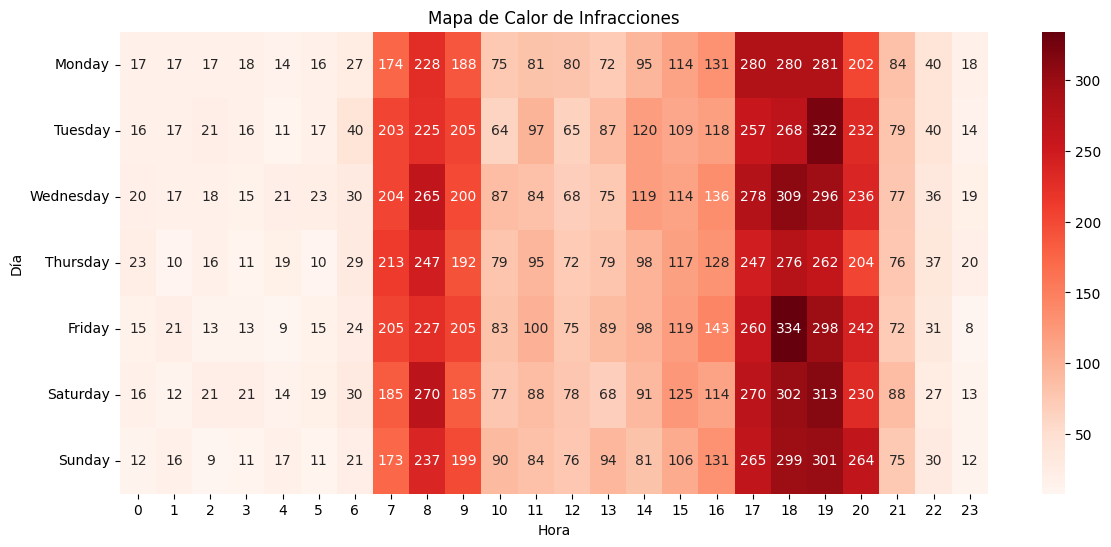

In [31]:
heatmap_data = (
    df[df["exceeded"] == True]
    .groupby(["day", "hour"])
    .size()
    .unstack(fill_value=0)
)

orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = heatmap_data.reindex(orden_dias)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Mapa de Calor de Infracciones")
plt.xlabel("Hora")
plt.ylabel("Día")

plt.show()

Qué demuestra
* Horarios críticos.
* Días más peligrosos.
* Patrones temporales.